# Module 2: USDA My Market News Project - Python GenAI

<a target="_blank" href="https://colab.research.google.com/github/yalinli2/EnvEtools/blob/main/course_modules/2_USDA_MyMarketNews_Python_GenAI.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a target="_blank" href="https:///mybinder.org/v2/gh/yalinli2/EnvEtools/main?urlpath=%2Fdoc%2Ftree%2Fcourse_modules%2F2_USDA_MyMarketNews_Python_GenAI.ipynb">
  <img src="https://mybinder.org/badge_logo.svg" alt="Open In Binder"/>
</a>

## Notes and Expectations
I view GenAI as a useful tool, if you can use it appropriately, rather than trusting it blindly.

<img src="../images/2_genai_policy.png" alt="Course Policy on GenAI" width=800>

Let's use this project to demonstrate how GenAI can be used. Below, I'll show the prompt I used and the response I got from [ChatGPT](https://chatgpt.com/) as an anonymous  user. Note that GenAI tools evolve very very quickly, they can remember your chat histories (unless you disable it), and the companies roll out new models constantly, so the reponse I got might be different from what you see.

Regardless, the key point is that you need to use your engineering judgement, domain expertise (a fancy word for "specialized knowledge"), and other reliable sources to validate the response you get. For coding, the best way is just to see whether you can get the resuls you want.

## Demo: Data Cleanup and Figure Generation
Assume we have exported the data from USDA My Market News, we'd like to ChatGPT to write the code that can generate the figure below
<img src="../images/2_price_by_type.png" alt="price by type" width=600/>

----- My Prompt -----

Assume you have an Excel file with three sheets: 1083, 1084, and 1085, write the Python code that can:
1. Extract the data from each of the three sheets for the following columns: Column1.group, Column1.report_date, Column1.region, Column1.price_min, Column1.price_max information.
2. Compile all extracted data together.
3. Make a grouped bar chart that show the average of the min price and max price for each of the group.

----- ChatGPT Response -----

Here’s a clean, end-to-end example using **pandas** and **matplotlib**.
I’ll assume:

* The Excel file is called `data.xlsx`
* Sheet names are exactly `"1083"`, `"1084"`, `"1085"`
* Column names are exactly as you wrote them

You can tweak names if needed.

```python
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Read and extract data
# -----------------------------
file_path = "data.xlsx"
sheets = ["1083", "1084", "1085"]

columns_needed = [
    "Column1.group",
    "Column1.report_date",
    "Column1.region",
    "Column1.price_min",
    "Column1.price_max"
]

df_list = []

for sheet in sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, usecols=columns_needed)
    df_list.append(df)

# -----------------------------
# 2. Compile all data together
# -----------------------------
all_data = pd.concat(df_list, ignore_index=True)

# -----------------------------
# 3. Calculate averages by group
# -----------------------------
grouped = (
    all_data
    .groupby("Column1.group")[["Column1.price_min", "Column1.price_max"]]
    .mean()
    .reset_index()
)

# -----------------------------
# 4. Grouped bar chart
# -----------------------------
groups = grouped["Column1.group"]
min_prices = grouped["Column1.price_min"]
max_prices = grouped["Column1.price_max"]

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, min_prices, width, label="Average Min Price")
plt.bar(x + width/2, max_prices, width, label="Average Max Price")

plt.xlabel("Group")
plt.ylabel("Price")
plt.title("Average Min and Max Prices by Group")
plt.xticks(x, groups, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
```

### What this does

* Pulls the same columns from all three sheets
* Stacks them into one dataset
* Computes **average min & max price per group**
* Plots a **grouped bar chart** so min vs max are side-by-side for each group

If you want:

* separate charts per region
* monthly averages using `report_date`
* seaborn styling
* export the compiled data back to Excel

just say the word 👌


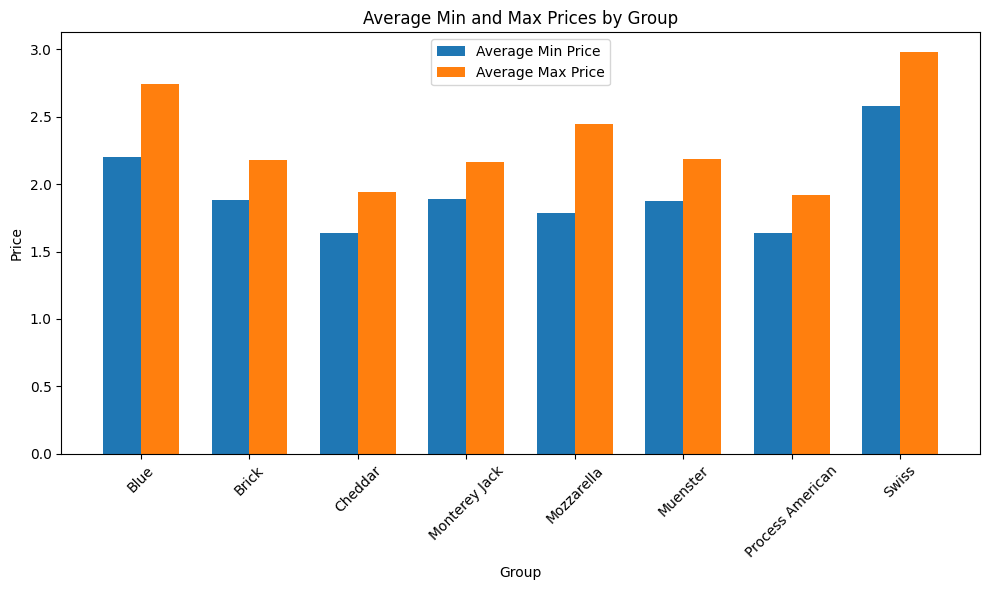

In [1]:
# Let's try it out
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Read and extract data
# -----------------------------
file_path = "data/2_MyMarketNewsSampleAPIv1.1.xlsx" # note that you need to update the file name
sheets = ["1083", "1084", "1085"]

columns_needed = [
    "Column1.group",
    "Column1.report_date",
    "Column1.region",
    "Column1.price_min",
    "Column1.price_max"
]

df_list = []

for sheet in sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, usecols=columns_needed)
    df_list.append(df)

# -----------------------------
# 2. Compile all data together
# -----------------------------
all_data = pd.concat(df_list, ignore_index=True)

# -----------------------------
# 3. Calculate averages by group
# -----------------------------
grouped = (
    all_data
    .groupby("Column1.group")[["Column1.price_min", "Column1.price_max"]]
    .mean()
    .reset_index()
)

# -----------------------------
# 4. Grouped bar chart
# -----------------------------
groups = grouped["Column1.group"]
min_prices = grouped["Column1.price_min"]
max_prices = grouped["Column1.price_max"]

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, min_prices, width, label="Average Min Price")
plt.bar(x + width/2, max_prices, width, label="Average Max Price")

plt.xlabel("Group")
plt.ylabel("Price")
plt.title("Average Min and Max Prices by Group")
plt.xticks(x, groups, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Not too shabby, right?😀

## In-Class Activity
Using your Python knowledge, or with the help of a GenAI tool, reproduce any of the figures we made in previous classes:
#### 1. Price trend over time.
<img src="../images/2_price_trend.png" alt="price trend" width=600>

#### 2. Price box plots by cheese type.
<img src="../images/2_box_plot.png" alt="box plot" width=600>

#### 3. Price histogram plot by cheese type.
<img src="../images/2_histograms.png" alt="box plot" width=600>

###

### Requirements
Show me the prompt you provide to your GenAI tool and its response, run the codes it provides, and show me the outputs. This is what I expect for your project submissions, if you choose to use GenAI.

You are dismissed if you finish the assignment!

**Note:**
I might ask some random questions throughout this process to make sure you understand what the tool/codes are doing.